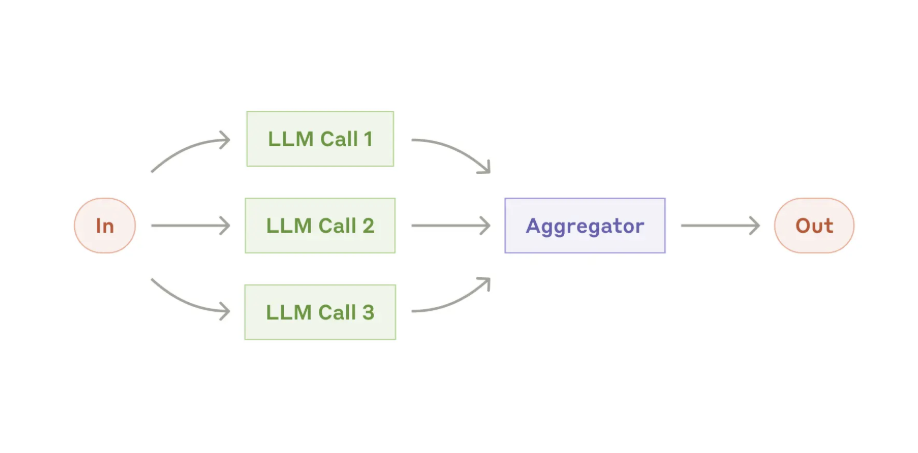

<a href="https://langchain-ai.github.io/langgraph/tutorials/workflows/">Source</a>

# 0.0. Configure

In [6]:
from dotenv import load_dotenv

In [7]:
load_dotenv()

True

# 1.0. Imports

In [3]:
from IPython.display import Image, display

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

# 2.0. Hands-On

In [4]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

In [ ]:
llm = ChatOpenAI(model="gpt-4o")

In [9]:
def call_llm_1(state: State):
    """First LLM call to generate a joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")

    return { "joke": msg.content }

def call_llm_2(state: State):
    """Second LLM call to generate a story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")

    return { "story": msg.content }

def call_llm_3(state: State):
    """Third LLM call to generate a poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")

    return { "poem": msg.content }

def aggregator(state: State):
    """Aggregates the outputs of the LLMs"""

    combined_output = f"Here is a storym joke, and poem about {state['topic']}:\n\n"
    combined_output += f"STORY: \n{state['story']}\n\n"
    combined_output += f"JOKE: \n{state['joke']}\n\n"
    combined_output += f"POEM: \n{state['poem']}\n\n"

    return { "combined_output": combined_output }

In [11]:
parallel_builder = StateGraph(State)

parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")

parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")

parallel_builder.add_edge("aggregator", END)

parallel_workflow = parallel_builder.compile()

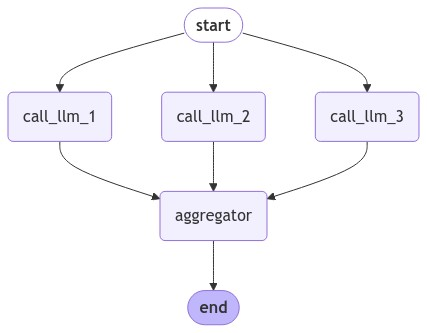

In [12]:
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# 3.0. Testing

In [13]:
state = parallel_workflow.invoke({"topic": "cars"})

In [20]:
state["topic"]

'cars'

In [16]:
state["joke"]

'Why did the car apply for a job?\n\nBecause it wanted to rev up its career!'

In [17]:
state["story"]

'Once upon a time in the bustling city of Autoville, where cars were not just vehicles but cherished members of the community, there lived a vibrant red convertible named Ruby. Ruby was known for her gleaming finish and her ability to turn heads as she zipped through the city streets. Her owner, a young mechanic named Jake, had inherited her from his grandfather, who had been a legendary racer in his time.\n\nRuby loved the stories Jake would tell about the races his grandfather had won, imagining herself speeding along the winding tracks, the wind rushing past her, and the roar of the crowd in her tires. However, those days seemed like distant dreams as Ruby spent most of her time parked in Jake’s modest garage, venturing out only for the occasional trip to the market or a leisurely Sunday drive.\n\nOne crisp autumn morning, as the leaves painted the city in shades of amber and gold, something extraordinary happened. A flyer landed on the windshield of every car in Autoville, announci

In [18]:
state["poem"]

"In the city streets and country lanes,  \nWhere asphalt hums and freedom reigns,  \nThe cars parade, a vibrant fleet,  \nWith stories whispered beneath their feet.  \n\nSleek silhouettes in colors bold,  \nMetallic dreams that tales unfold,  \nEngines roar like lions' cries,  \nChasing sunsets, kissing skies.  \n\nChrome and leather, crafted grace,  \nIn endless journeys they embrace,  \nFrom dawn's first light to twilight's fall,  \nTheir whispered secrets echo all.  \n\nThrough rain-soaked nights and sunlit days,  \nThey dance on highways, winding ways,  \nA symphony of gears and speed,  \nIn every heart, they plant a seed.  \n\nFor some, a chariot of dreams untold,  \nFor others, warmth in winter's cold,  \nWith windows down, the world they greet,  \nA symphony of wheels and street.  \n\nIn parking lots, they rest awhile,  \nBeneath the moon's approving smile,  \nYet always ready, engines warm,  \nTo guide us through life's endless storm.  \n\nOh, cars, you vessels of our quest,  \

In [21]:
print(state["combined_output"])

Here is a storym joke, and poem about cars:

STORY: 
Once upon a time in the bustling city of Autoville, where cars were not just vehicles but cherished members of the community, there lived a vibrant red convertible named Ruby. Ruby was known for her gleaming finish and her ability to turn heads as she zipped through the city streets. Her owner, a young mechanic named Jake, had inherited her from his grandfather, who had been a legendary racer in his time.

Ruby loved the stories Jake would tell about the races his grandfather had won, imagining herself speeding along the winding tracks, the wind rushing past her, and the roar of the crowd in her tires. However, those days seemed like distant dreams as Ruby spent most of her time parked in Jake’s modest garage, venturing out only for the occasional trip to the market or a leisurely Sunday drive.

One crisp autumn morning, as the leaves painted the city in shades of amber and gold, something extraordinary happened. A flyer landed on th